# agentv24_production_deployment_pattern

This version wraps a LangGraph agent as a production-style FastAPI service.

API endpoints:

```text
GET  /health
GET  /ready
POST /invoke
POST /stream
```


## 1. Install dependencies

```bash
pip install -U fastapi uvicorn langgraph langchain langchain-openai langsmith python-dotenv httpx ipython jupyter
```


In [2]:
# Optional: uncomment in a fresh environment.
# %pip install -U fastapi uvicorn langgraph langchain langchain-openai langsmith python-dotenv httpx ipython jupyter


## 2. Load environment variables


In [3]:
from pathlib import Path
import os
from dotenv import load_dotenv

cwd = Path.cwd()
load_dotenv(cwd / ".env")
load_dotenv(cwd.parent / ".env")

print("OpenAI API key present:", bool(os.getenv("OPENAI_API_KEY")))
print("LangSmith tracing:", os.getenv("LANGSMITH_TRACING"))
print("LangSmith project:", os.getenv("LANGSMITH_PROJECT"))


OpenAI API key present: True
LangSmith tracing: true
LangSmith project: langgraph-playground


## 3. Define settings and state


In [4]:
from dataclasses import dataclass
from typing import NotRequired, TypedDict

@dataclass(frozen=True)
class Settings:
    app_name: str = "agentv24-production-agent"
    model_name: str = os.getenv("MODEL_NAME", "gpt-4o-mini")
    temperature: float = float(os.getenv("TEMPERATURE", "0"))

settings = Settings()

class AgentState(TypedDict):
    input: str
    request_id: str
    context: NotRequired[dict]
    classification: NotRequired[str]
    analysis: NotRequired[str]
    final_answer: NotRequired[str]


## 4. Build graph


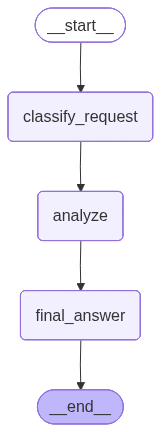

In [5]:
from langchain_openai import ChatOpenAI
from langgraph.graph import START, END, StateGraph

def classify_request_node(state: AgentState) -> AgentState:
    text = state["input"].lower()

    if any(term in text for term in ["latency", "timeout", "failure", "incident", "error"]):
        classification = "incident_analysis"
    elif any(term in text for term in ["sql", "metric", "volume", "count"]):
        classification = "analytics"
    else:
        classification = "general"

    return {"classification": classification}

def analyze_node(state: AgentState) -> AgentState:
    llm = ChatOpenAI(model=settings.model_name, temperature=settings.temperature)

    prompt = f'''
You are a production LangGraph agent.

Request id:
{state["request_id"]}

Classification:
{state["classification"]}

Optional context:
{state.get("context", {})}

User request:
{state["input"]}

Produce a concise operational analysis.
'''

    response = llm.invoke(prompt)
    return {"analysis": response.content}

def final_answer_node(state: AgentState) -> AgentState:
    return {
        "final_answer": (
            f"Classification: {state['classification']}\n\n"
            f"{state['analysis']}"
        )
    }

def build_graph():
    graph_builder = StateGraph(AgentState)

    graph_builder.add_node("classify_request", classify_request_node)
    graph_builder.add_node("analyze", analyze_node)
    graph_builder.add_node("final_answer", final_answer_node)

    graph_builder.add_edge(START, "classify_request")
    graph_builder.add_edge("classify_request", "analyze")
    graph_builder.add_edge("analyze", "final_answer")
    graph_builder.add_edge("final_answer", END)

    return graph_builder.compile()

graph = build_graph()
graph


## 5. Test local graph invocation


In [6]:
result = graph.invoke({
    "input": "Investigate CHECK-DOMAIN timeout spike after release R13.",
    "request_id": "req_notebook_001",
    "context": {
        "command": "CHECK-DOMAIN",
        "release": "R13",
    },
})

print(result["final_answer"])


Classification: incident_analysis

### Operational Analysis: CHECK-DOMAIN Timeout Spike Post Release R13

#### Overview
Following the deployment of Release R13, a significant spike in timeouts for the CHECK-DOMAIN command has been observed. This analysis aims to identify potential causes and recommend actions to mitigate the issue.

#### Key Findings

1. **Increased Load**: 
   - Post-release, there was a notable increase in the number of requests for the CHECK-DOMAIN command, likely due to new features or changes that prompted higher usage.

2. **Code Changes**:
   - Review of the release notes indicates modifications to the CHECK-DOMAIN logic, including additional validation checks and external API calls, which may have contributed to increased processing time.

3. **External Dependencies**:
   - The CHECK-DOMAIN command relies on third-party services for domain validation. Any latency or downtime from these services can directly impact the command's performance.

4. **Infrastructure

## 6. Stream graph updates locally


In [7]:
async for chunk in graph.astream(
    {
        "input": "Stream EPP incident analysis.",
        "request_id": "req_stream_notebook",
        "context": {"command": "CHECK-DOMAIN"},
    },
    stream_mode="updates",
):
    print("\n--- update ---")
    print(chunk)



--- update ---
{'classify_request': {'classification': 'incident_analysis'}}

--- update ---
{'analyze': {'analysis': '### Operational Analysis: EPP Incident\n\n**Incident Overview:**\nThe EPP (Endpoint Protection Platform) incident involves a potential security breach or malfunction affecting endpoint security measures. This analysis aims to identify the root cause, impact, and recommended actions.\n\n**1. Incident Identification:**\n- **Date/Time of Incident:** [Insert Date/Time]\n- **Detection Method:** Automated alerts from EPP systems indicating unusual activity or policy violations.\n\n**2. Scope of Impact:**\n- **Affected Systems:** List of endpoints impacted (e.g., workstations, servers).\n- **User Impact:** Number of users affected and potential data exposure.\n- **Business Impact:** Assessment of operational disruption and potential financial implications.\n\n**3. Root Cause Analysis:**\n- **Initial Findings:** \n  - Misconfiguration of EPP settings.\n  - Outdated virus defi

## 7. Run API server

In terminal:

```bash
python -m agentv24_production_deployment_pattern.api_server
```

Then test:

```bash
python -m agentv24_production_deployment_pattern.smoke_client
```
